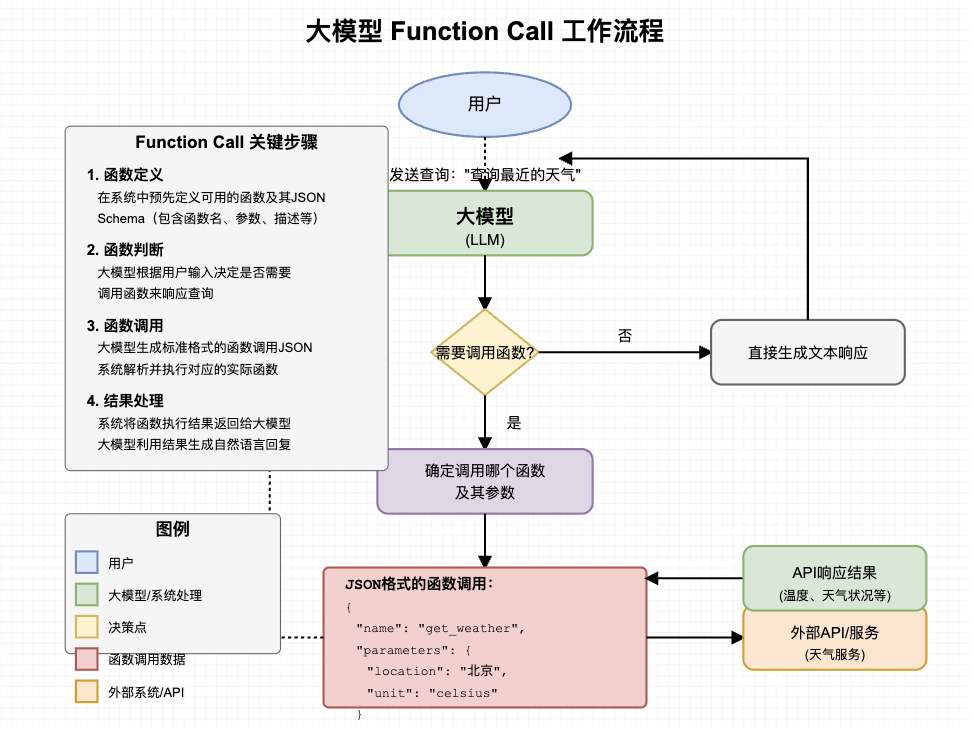

In [1]:
import requests

def get_weather(latitude, longitude):
    response = requests.get(f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current=temperature_2m,wind_speed_10m&hourly=temperature_2m,relative_humidity_2m,wind_speed_10m")
    data = response.json()
    return data['current']['temperature_2m']

In [27]:
from openai import OpenAI
import json

client = OpenAI(api_key='')

tools = [{
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get current temperature for provided coordinates in celsius.",
        "parameters": {
            "type": "object",
            "properties": {
                "latitude": {"type": "number"},
                "longitude": {"type": "number"}
            },
            "required": ["latitude", "longitude"],
            "additionalProperties": False
        },
        "strict": True
    }
}]

messages = [{"role": "user", "content": "What's the weather like in Paris today?"}]

completion = client.chat.completions.create(
    model="gpt-4o",
    messages=messages,
    tools=tools,
)

In [33]:
print(completion.choices[0].message.tool_calls)

[ChatCompletionMessageToolCall(id='call_XDDFphP1J4K9uo4CyqNVB6YU', function=Function(arguments='{"latitude":48.8566,"longitude":2.3522}', name='get_weather'), type='function')]


In [35]:
tool_call = completion.choices[0].message.tool_calls[0]
args = json.loads(tool_call.function.arguments)

result = get_weather(args["latitude"], args["longitude"])

In [37]:
messages.append(completion.choices[0].message)  # append model's function call message
messages.append({                               # append result message
    "role": "tool",
    "tool_call_id": tool_call.id,
    "content": str(result)
})

completion_2 = client.chat.completions.create(
    model="gpt-4o",
    messages=messages,
    tools=tools,
)

In [39]:
completion_2.choices[0].message.content

'The current temperature in Paris is 14.2°C.'